<a href="https://colab.research.google.com/github/AhmadObaidat/School/blob/main/Image_Classification_with_Transfer_Learning_(tf_flowers_%2B_EfficientNetB0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TF version: 2.19.0
TFDS version: 4.9.9

=== DATASET INFO ===
Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Num classes: 5
Total images: 3670
Train samples per class: Counter({0: 739, 2: 613, 3: 561, 1: 513, 4: 510})
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

=== MODEL SUMMARY ===


Model: "tf_flowers_efficientnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


===== Phase 1: Training head only (base frozen) =====
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.6032 - loss: 1.0625 - val_accuracy: 0.8665 - val_loss: 0.4243
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8514 - loss: 0.4542 - val_accuracy: 0.8992 - val_loss: 0.3199
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8895 - loss: 0.3480 - val_accuracy: 0.8965 - val_loss: 0.2854
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9124 - loss: 0.2913 - val_accuracy: 0.9101 - val_loss: 0.2525
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9022 - loss: 0.2945 - val_accuracy: 0.9128 - val_loss: 0.2370
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9237 - loss: 0.2594 - val_accuracy: 0.9237 - val_loss: 0.2322
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9261 - loss: 0.2366 - val_accuracy: 0.9183 - val_loss: 0.2250
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - ac

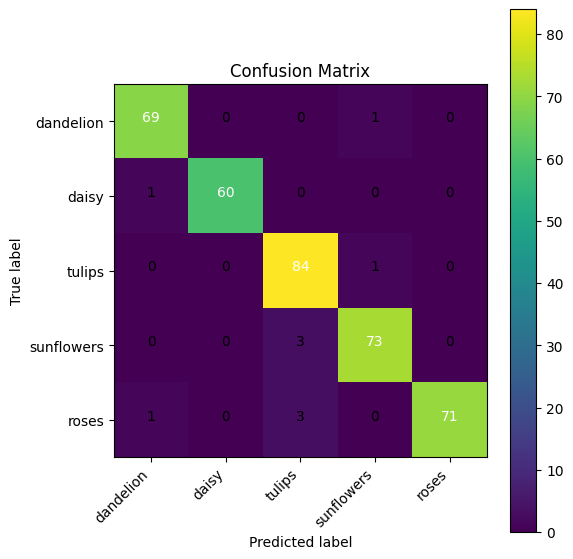

Normalized confusion matrix


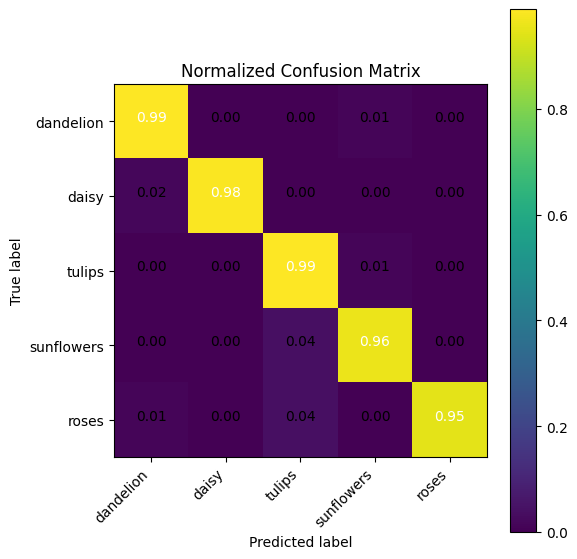


All done ✅


In [ ]:
# ============================================
# WK6 - Image Classification with Transfer Learning (tf_flowers + EfficientNetB0)
# Fixed preprocessing version - ONE SCRIPT FOR EVERYTHING
# ============================================

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import itertools
import collections
import time

print("TF version:", tf.__version__)
print("TFDS version:", tfds.__version__)

# ============================================
# 1. CONFIG
# ============================================

DATASET_NAME = "tf_flowers"
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

initial_epochs = 10      # phase 1: train head only
fine_tune_epochs = 10    # phase 2: fine-tune top layers
total_epochs = initial_epochs + fine_tune_epochs

# ============================================
# 2. LOAD DATASET & SPLIT (train / val / test)
# ============================================

# tf_flowers has a single 'train' split, so we slice it manually
(train_raw, val_raw, test_raw), info = tfds.load(
    DATASET_NAME,
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True
)

num_classes = info.features['label'].num_classes
class_names = info.features['label'].names

print("\n=== DATASET INFO ===")
print("Classes:", class_names)
print("Num classes:", num_classes)
print("Total images:", info.splits['train'].num_examples)

# Optional: verify >100 images per class in the training split
def count_per_class(ds):
    counter = collections.Counter()
    for _, label in ds:
        counter[int(label.numpy())] += 1
    return counter

train_counts = count_per_class(train_raw)
print("Train samples per class:", train_counts)

# ============================================
# 3. PREPROCESSING & DATA PIPELINE
# ============================================

# Data augmentation (only applied on training)
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)

# IMPORTANT FIX:
# Do NOT divide by 255 here because EfficientNet's preprocess_input
# expects images in [0, 255] and handles scaling internally.
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)  # <-- NO /255.0
    return image, label

def prepare_dataset(ds, shuffle=False):
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = prepare_dataset(train_raw, shuffle=True)
val_ds   = prepare_dataset(val_raw, shuffle=False)
test_ds  = prepare_dataset(test_raw, shuffle=False)

# Optional: visualize some samples
def show_sample_batch(dataset):
    for images, labels in dataset.take(1):
        plt.figure(figsize=(8, 8))
        for i in range(9):
            if i >= images.shape[0]:
                break
            plt.subplot(3, 3, i+1)
            plt.imshow(tf.cast(images[i], tf.uint8))
            plt.title(class_names[int(labels[i])])
            plt.axis("off")
        plt.tight_layout()
        plt.show()

# Uncomment to inspect a batch
# show_sample_batch(train_ds)

# ============================================
# 4. BUILD TRANSFER LEARNING MODEL (EfficientNetB0)
# ============================================

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # freeze base for phase 1

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Apply augmentation only during training
x = data_augmentation(inputs)

# EfficientNet preprocessing (expects [0, 255] float32)
x = preprocess_input(x)

# Base model
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs, name="tf_flowers_efficientnet")

print("\n=== MODEL SUMMARY ===")
model.summary()

# ============================================
# 5. TRAINING - PHASE 1: FEATURE EXTRACTION
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n===== Phase 1: Training head only (base frozen) =====")
start_time = time.time()
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs
)
print("Phase 1 training time (min):", (time.time() - start_time) / 60.0)

# ============================================
# 6. FINE-TUNING - PHASE 2
# ============================================

# Unfreeze the base model
base_model.trainable = True

# Optionally: keep lower layers frozen, fine-tune only top N layers
# Here we fine-tune the top 20 layers of the base model
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n===== Phase 2: Fine-tuning top layers =====")
start_time = time.time()
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_1.epoch[-1] + 1
)
print("Phase 2 training time (min):", (time.time() - start_time) / 60.0)

# ============================================
# 7. EVALUATION ON TEST SET
# ============================================

print("\n===== Evaluate on test set =====")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# ============================================
# 8. DETAILED METRICS: CLASSIFICATION REPORT & CONFUSION MATRIX
# ============================================

y_true = []
y_pred = []

print("\nCollecting predictions on test set...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n===== Classification Report =====")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix")
plot_confusion_matrix(cm, class_names, normalize=True, title="Normalized Confusion Matrix")

print("\nAll done ✅")


AttributeError: 'str' object has no attribute 'numpy'

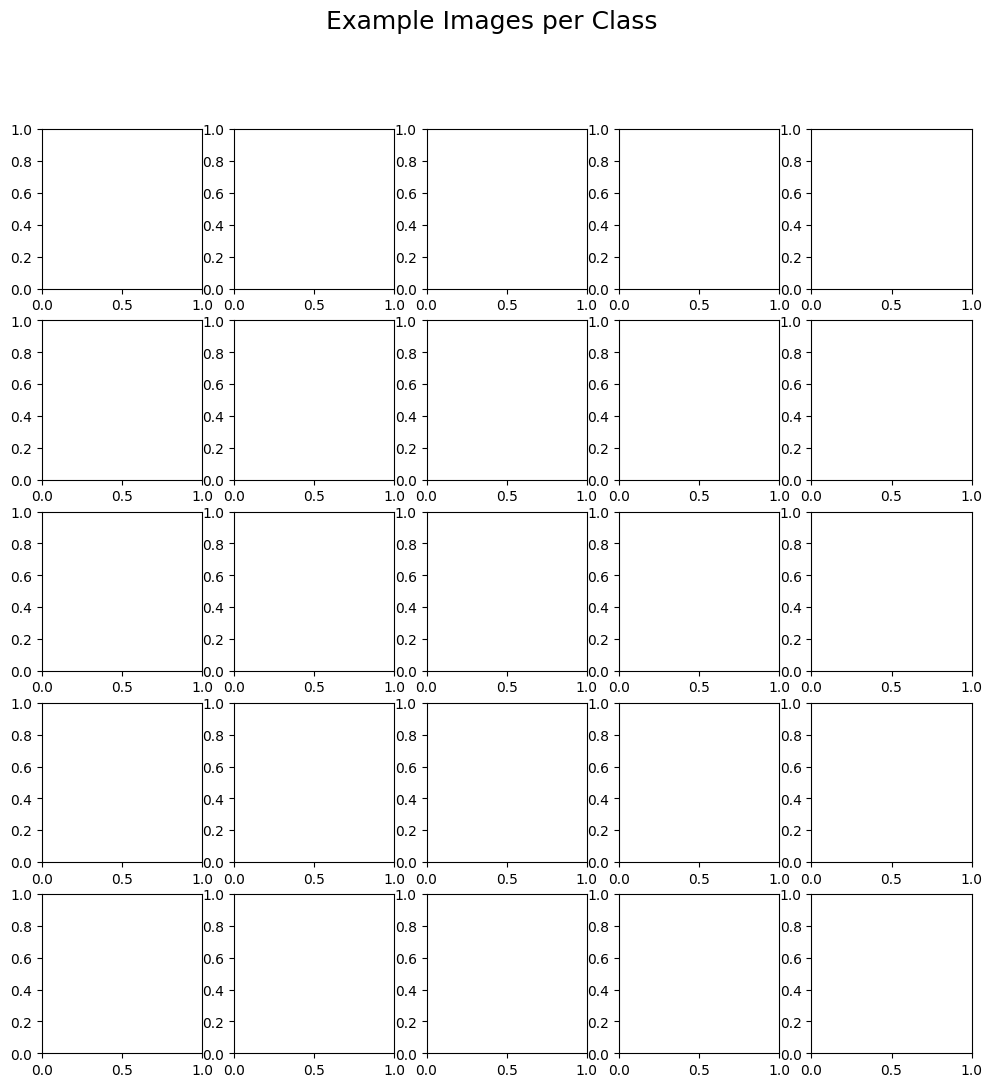

In [ ]:
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

ds, info = tfds.load("tf_flowers", split="train", with_info=True)

class_names = info.features["label"].names
num_classes = len(class_names)

fig, axes = plt.subplots(num_classes, 5, figsize=(12, 12))
fig.suptitle("Example Images per Class", fontsize=18)

samples_per_class = {i: 0 for i in range(num_classes)}

for image, label in ds.shuffle(2000):
    label = int(label.numpy())
    if samples_per_class[label] < 5:
        ax = axes[label][samples_per_class[label]]
        ax.imshow(image)
        ax.set_title(class_names[label])
        ax.axis("off")
        samples_per_class[label] += 1
    if all(v == 5 for v in samples_per_class.values()):
        break

plt.tight_layout()
plt.show()


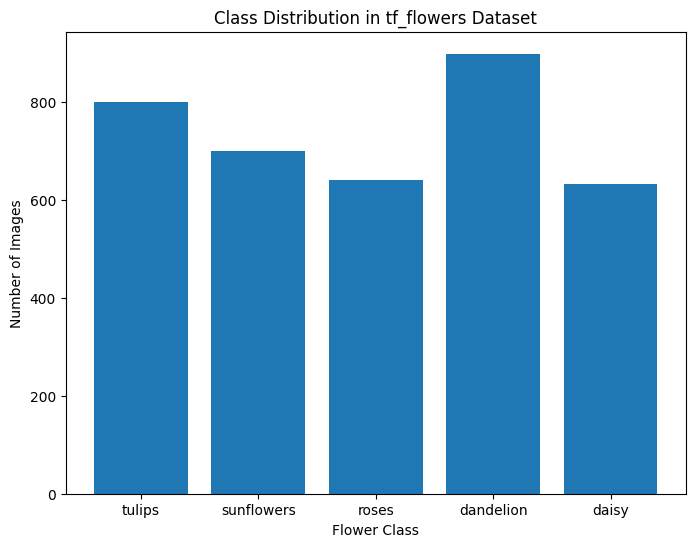

In [ ]:
import matplotlib.pyplot as plt
import collections
import tensorflow_datasets as tfds

ds = tfds.load("tf_flowers", split="train", as_supervised=True)

counts = collections.Counter()
for _, label in ds:
    counts[int(label.numpy())] += 1

labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(8,6))
plt.bar([class_names[i] for i in labels], values)
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in tf_flowers Dataset")
plt.show()


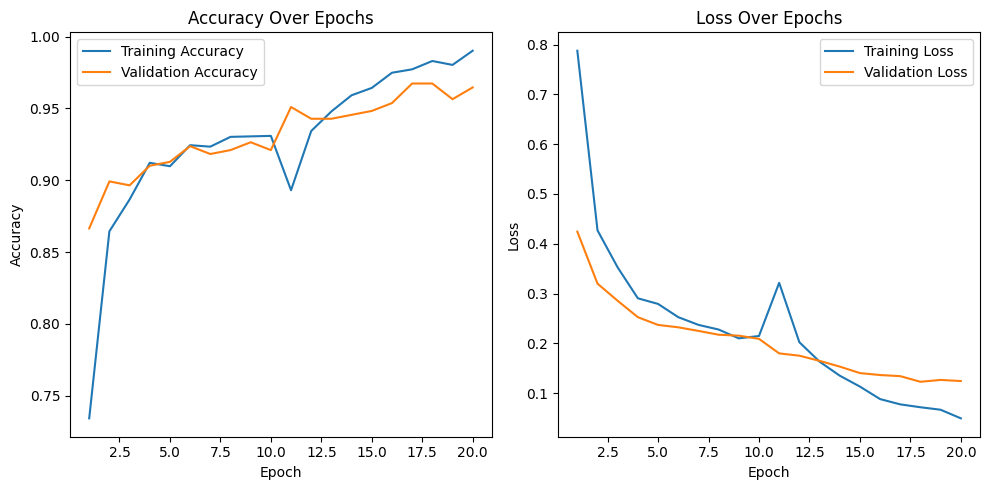

In [ ]:
import matplotlib.pyplot as plt

acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']

loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


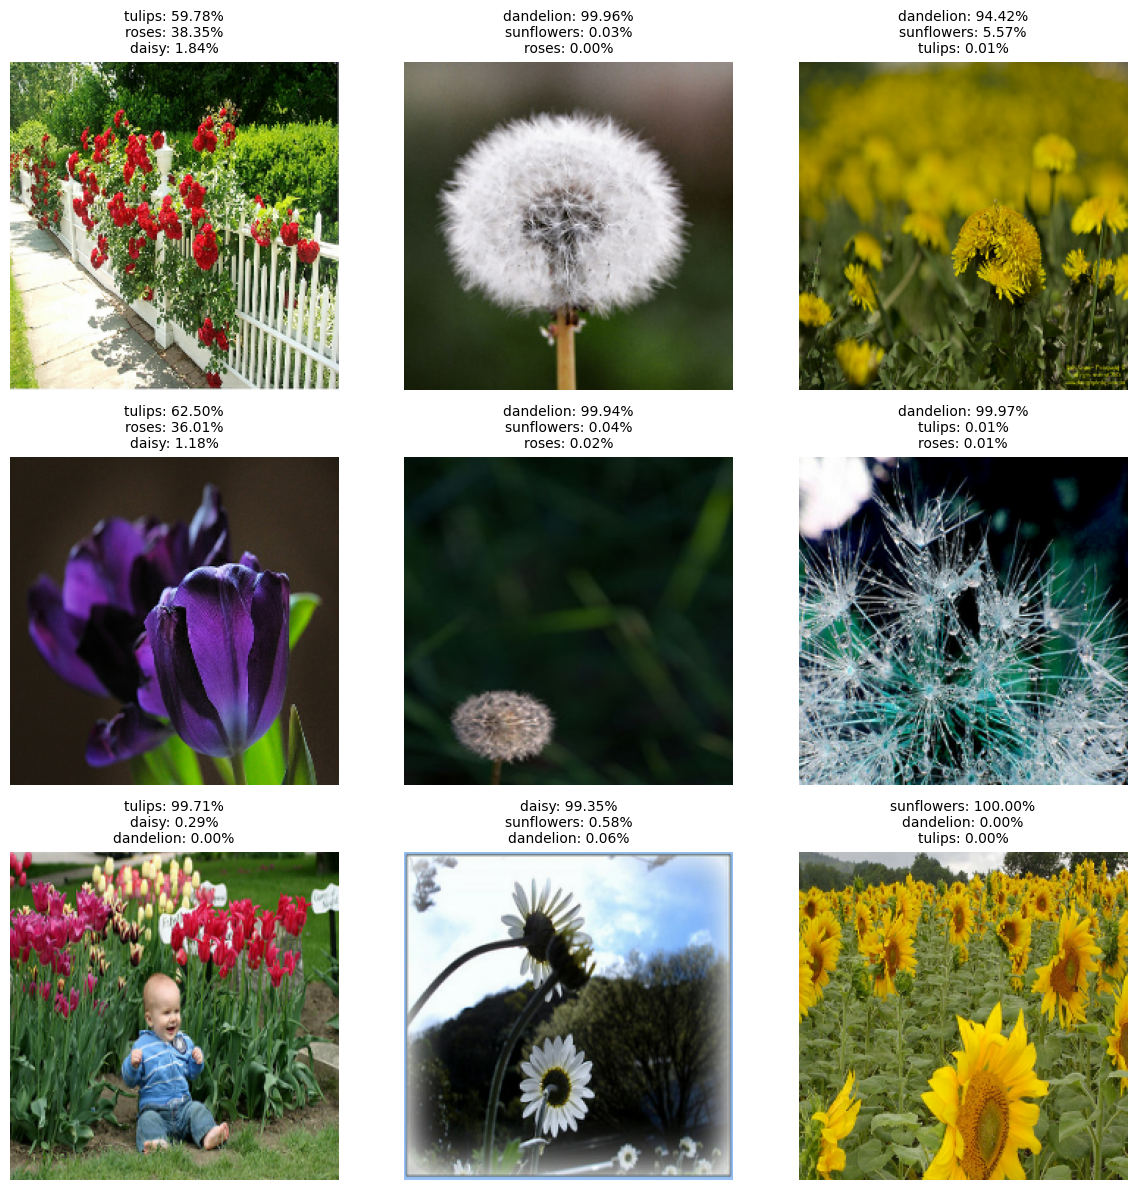

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    top3 = np.argsort(preds, axis=1)[:, -3:]

    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

        pred_labels = [class_names[j] for j in top3[i][::-1]]
        pred_probs  = [preds[i][j] for j in top3[i][::-1]]

        title = "\n".join([f"{pred_labels[k]}: {pred_probs[k]*100:.2f}%" for k in range(3)])
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step


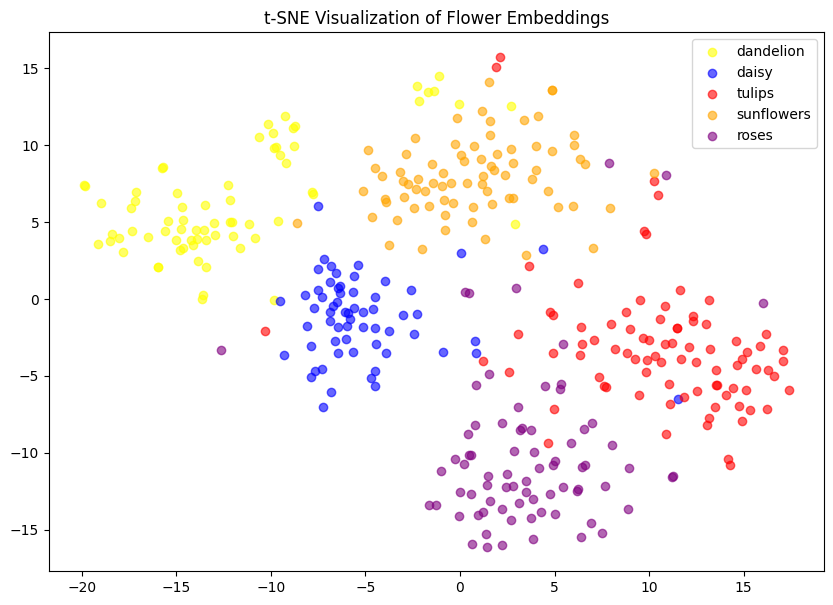

In [ ]:
from sklearn.manifold import TSNE

# Extract embeddings
embed_model = tf.keras.Model(model.input, model.layers[-3].output)

all_images = []
all_labels = []

for images, labels in test_ds:
    all_images.append(images)
    all_labels.append(labels)

all_images = tf.concat(all_images, axis=0)
all_labels = tf.concat(all_labels, axis=0)

embeddings = embed_model.predict(all_images)

# Run t-SNE
tsne = TSNE(n_components=2, learning_rate='auto')
tsne_results = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 7))
colors = ['yellow', 'blue', 'red', 'orange', 'purple']

for i, c in enumerate(colors):
    idx = (all_labels.numpy() == i)
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], c=c, label=class_names[i], alpha=0.6)

plt.title("t-SNE Visualization of Flower Embeddings")
plt.legend()
plt.show()
